In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [5]:
df = pd.read_csv("EMS_Cleaned.csv")

print(df.shape)

df.head()

(1655433, 25)


,incident_datetime,initial_call_type,final_call_type,first_assignment_datetime,first_activation_datetime,first_on_scene_datetime,first_to_hosp_datetime,incident_close_datetime,dispatch_response_seconds_qy,incident_response_seconds_qy,...,month,weekday,Weekend,Year,Month,Day,Hour,Weekday,incident_duration,dispatch_delay
0,2024-01-01 00:00:03,53.0,51.0,2024-01-01 00:00:56,2024-01-01 00:01:13,2024-01-01 00:06:36,2024-04-05 20:03:50,2024-01-01 00:56:41,53.0,393.0,...,1.0,1.0,False,2024.0,1.0,1.0,0.0,1.0,3398.0,53.0
1,2024-01-01 00:00:14,21.0,17.0,2024-01-01 00:01:38,2024-01-01 00:01:54,2024-01-01 00:07:24,2024-01-01 00:26:07,2024-01-01 01:19:22,84.0,430.0,...,1.0,1.0,False,2024.0,1.0,1.0,0.0,1.0,4748.0,84.0
2,2024-01-01 00:00:18,99.0,111.0,2024-01-01 10:17:05,2024-01-01 10:17:05,2024-01-01 10:24:18,2024-01-01 12:26:21,2024-01-01 14:20:21,0.0,NaN,...,1.0,1.0,False,2024.0,1.0,1.0,0.0,1.0,9640.5,191.5
3,2024-01-01 00:00:45,84.0,95.0,2024-01-01 00:25:30,2024-01-01 00:25:40,2024-01-01 00:32:59,2024-01-01 00:50:41,2024-01-01 01:37:04,1485.0,1934.0,...,1.0,1.0,False,2024.0,1.0,1.0,0.0,1.0,5779.0,191.5
4,2024-01-01 00:00:55,20.0,16.0,2024-01-01 00:01:34,2024-01-01 00:01:57,2024-01-01 00:22:50,2024-01-01 01:27:23,2024-01-01 02:36:27,39.0,1315.0,...,1.0,1.0,False,2024.0,1.0,1.0,0.0,1.0,9332.0,39.0


In [6]:
df["incident_datetime"] = pd.to_datetime(
    df["incident_datetime"],
    errors="coerce"
)

df = df.dropna(subset=["incident_datetime"])

In [7]:
hourly = (

    df

    .groupby(

        pd.Grouper(

            key="incident_datetime",

            freq="h"

        )

    )

    .size()

    .reset_index(name="incident_count")

)

hourly.head()

,incident_datetime,incident_count
0,2024-01-01 00:00:00,229
1,2024-01-01 01:00:00,259
2,2024-01-01 02:00:00,223
3,2024-01-01 03:00:00,191
4,2024-01-01 04:00:00,170


In [9]:
hourly["hour"] = hourly["incident_datetime"].dt.hour

hourly["day"] = hourly["incident_datetime"].dt.day

hourly["month"] = hourly["incident_datetime"].dt.month

hourly["weekday"] = hourly["incident_datetime"].dt.weekday

hourly["weekend"] = (

    hourly["weekday"] >= 5

).astype(int)

In [10]:
hourly["hour"] = hourly["incident_datetime"].dt.hour

hourly["day"] = hourly["incident_datetime"].dt.day

hourly["month"] = hourly["incident_datetime"].dt.month

hourly["weekday"] = hourly["incident_datetime"].dt.weekday

hourly["weekend"] = (

    hourly["weekday"] >= 5

).astype(int)

In [16]:
hourly["lag1"] = hourly["incident_count"].shift(1)

hourly["lag2"] = hourly["incident_count"].shift(2)

hourly["lag3"] = hourly["incident_count"].shift(3)

hourly = hourly.dropna()

print(hourly.head())

    incident_datetime  incident_count  hour  day  month  weekday  weekend  \
3 2024-01-01 03:00:00             191     3    1      1        0        0   
4 2024-01-01 04:00:00             170     4    1      1        0        0   
5 2024-01-01 05:00:00             176     5    1      1        0        0   
6 2024-01-01 06:00:00             187     6    1      1        0        0   
7 2024-01-01 07:00:00             165     7    1      1        0        0   

    lag1   lag2   lag3  
3  223.0  259.0  229.0  
4  191.0  223.0  259.0  
5  170.0  191.0  223.0  
6  176.0  170.0  191.0  
7  187.0  176.0  170.0  


In [17]:
features = [

    "hour",

    "day",

    "month",

    "weekday",

    "weekend",

    "lag1",

    "lag2",

    "lag3"

]

In [18]:
print(hourly.columns)

Index(['incident_datetime', 'incident_count', 'hour', 'day', 'month',
       'weekday', 'weekend', 'lag1', 'lag2', 'lag3'],
      dtype='object')


In [19]:
target = "incident_count"

In [20]:
X = hourly[features]

y = hourly[target]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    shuffle=False

)

In [22]:
models = {

    "Linear Regression":

        LinearRegression(),

    "Random Forest":

        RandomForestRegressor(

            n_estimators=100,

            max_depth=15,

            random_state=42,

            n_jobs=-1

        ),

    "XGBoost":

        XGBRegressor(

            n_estimators=300,

            learning_rate=0.05,

            max_depth=8,

            subsample=0.8,

            colsample_bytree=0.8,

            objective="reg:squarederror",

            tree_method="hist",

            random_state=42,

            n_jobs=-1

        )

}

In [23]:
results = []

trained_models = {}

for name, model in models.items():

    print("="*60)

    print(name)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(

        y_test,

        pred

    )

    rmse = np.sqrt(

        mean_squared_error(

            y_test,

            pred

        )

    )

    r2 = r2_score(

        y_test,

        pred

    )

    results.append([

        name,

        mae,

        rmse,

        r2

    ])

    trained_models[name] = model

    print("MAE :", round(mae,2))

    print("RMSE:", round(rmse,2))

    print("R2 :", round(r2,4))

Linear Regression
MAE : 18.73
RMSE: 24.2
R2 : 0.8076
Random Forest
MAE : 13.72
RMSE: 17.91
R2 : 0.8946
XGBoost
MAE : 13.84
RMSE: 18.0
R2 : 0.8936


In [25]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2 Score"

    ]

)

results_df.sort_values(

    by="R2 Score",

    ascending=False,

    inplace=True

)

results_df

,Model,MAE,RMSE,R2 Score
1,Random Forest,13.720138,17.913575,0.894592
2,XGBoost,13.837945,17.999327,0.893580
0,Linear Regression,18.734843,24.200429,0.807622


In [26]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model :", best_model_name)

Best Model : Random Forest


   Feature  Importance
0     hour    0.761217
5     lag1    0.151503
6     lag2    0.027399
7     lag3    0.019139
1      day    0.012588
3  weekday    0.012077
2    month    0.010356
4  weekend    0.005720


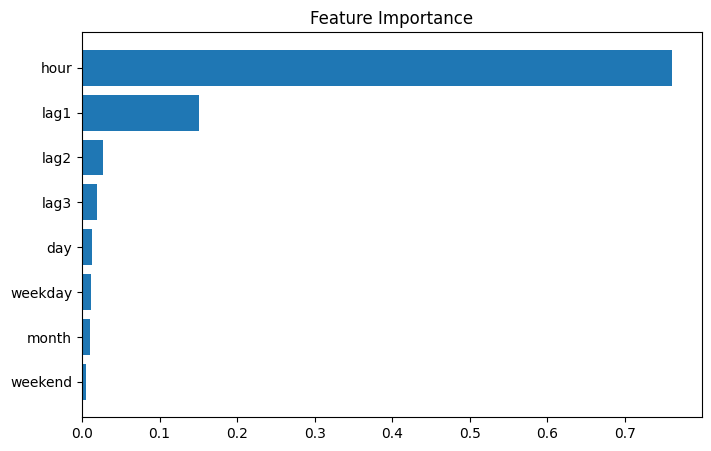

In [27]:
if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    print(importance)

    plt.figure(figsize=(8,5))

    plt.barh(

        importance["Feature"],

        importance["Importance"]

    )

    plt.gca().invert_yaxis()

    plt.title("Feature Importance")

    plt.show()

else:

    print("Feature Importance Not Available")

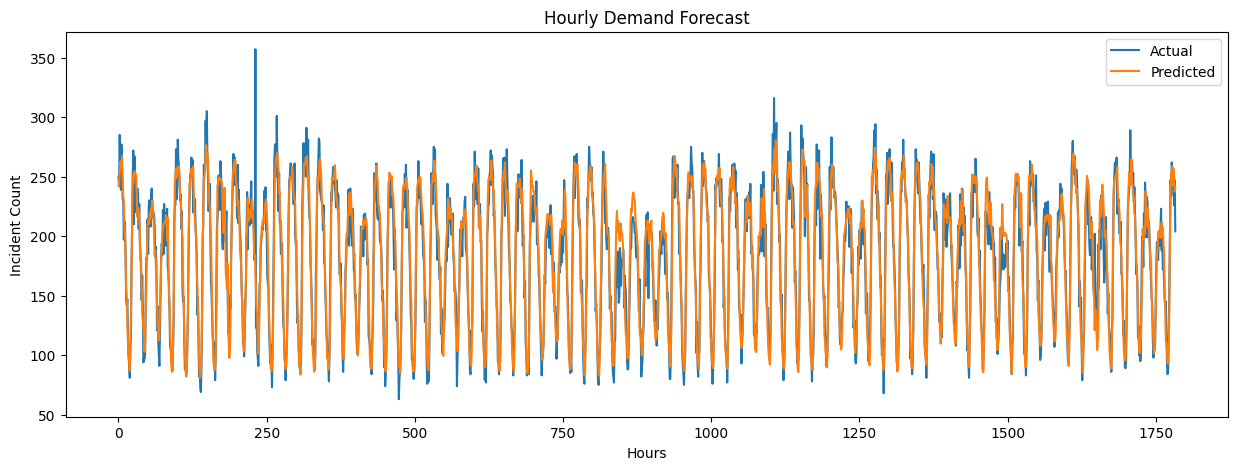

In [28]:
pred = best_model.predict(X_test)

plt.figure(figsize=(15,5))

plt.plot(

    y_test.values,

    label="Actual"

)

plt.plot(

    pred,

    label="Predicted"

)

plt.title("Hourly Demand Forecast")

plt.xlabel("Hours")

plt.ylabel("Incident Count")

plt.legend()

plt.show()

In [29]:
comparison = pd.DataFrame({

    "Actual": y_test.values[:10],

    "Predicted": pred[:10].round(2)

})

comparison

,Actual,Predicted
0,250,242.40
1,242,241.97
2,285,251.47
3,258,262.62
4,239,259.03
5,277,256.86
6,256,267.11
7,231,249.32
8,231,233.24
9,197,228.46


In [30]:
joblib.dump(

    best_model,

    "demand_forecast_model.pkl"

)

print("Demand Forecast Model Saved Successfully!")

Demand Forecast Model Saved Successfully!


In [31]:
files.download(

    "demand_forecast_model.pkl"

)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>